# Evaluacion Parcial 3 - Programacion para la ciencia de datos

- CARLOS ACEVEDO ALBERTO CANGAS (EL CAPITAN)

- Jean Bizama

- Joaquìn Muñoz

# 1. Importacion de librerias

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import davies_bouldin_score, silhouette_score, accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.utils import resample
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

# 2. Generacion de DataFrame

In [91]:
df = pd.read_csv('/content/googleplaystore.csv')
df = df.drop_duplicates().copy() #Se eliminan los datos duplicados en caso de haber
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [92]:
#Dejamos los datos mas relevantes para predecir el Rating de una app
df_relevante = df[["Rating","Category", "Reviews", "Size", "Type", "Price"]].copy()
df_relevante.head(3)

,Rating,Category,Reviews,Size,Type,Price
0,4.1,ART_AND_DESIGN,159,19M,Free,0
1,3.9,ART_AND_DESIGN,967,14M,Free,0
2,4.7,ART_AND_DESIGN,87510,8.7M,Free,0


In [93]:
#Durante la creacion del codigo descubrimos una fila con datos erroneos
print(df_relevante[df_relevante['Price'] == 'Everyone'])
#Conservamos el dataset sin esa fila
df_relevante = df_relevante[df_relevante['Price'] != 'Everyone']

       Rating Category Reviews    Size Type     Price
10472    19.0      1.9    3.0M  1,000+    0  Everyone


# 3. Limpieza del dataset relevante

In [94]:
#Es necesario hacer un tratamiento de datos nulos en las columnas 'Rating' y 'Type'
df_relevante.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Rating    8892 non-null   float64
 1   Category  10357 non-null  object 
 2   Reviews   10357 non-null  object 
 3   Size      10357 non-null  object 
 4   Type      10356 non-null  object 
 5   Price     10357 non-null  object 
dtypes: float64(1), object(5)
memory usage: 566.4+ KB


In [95]:
#Eliminamos la fila que tiene el nulo ya que solo es 1 dato
df_relevante.dropna(subset=['Type'], inplace=True)

mediana_rating = df['Rating'].median()
df_relevante['Rating'] = df['Rating'].fillna(mediana_rating)

#Limpiamos 'Price' Quitamos el símbolo '$' y convertimos a decimal
df_relevante['Price'] = df_relevante['Price'].astype(str).str.replace('$', '', regex=False).astype(float)
#Decidimos poner un umbral de precio en 50$, detectando como outliers a los de mayor precio
outliers_price = df_relevante[df_relevante['Price'] > 50]
df_relevante = df_relevante.drop(outliers_price.index)

#Limpiamos 'Reviews' Convirtiendolo directamente a entero
df_relevante['Reviews'] = df_relevante['Reviews'].astype(int)

#SIZE
#Estandarizar el size
for i, valor in enumerate(df_relevante['Size']):
    if pd.isnull(valor) or valor == 'Varies with device':
      df_relevante.iloc[i, df_relevante.columns.get_loc('Size')] = np.nan
    elif 'M' in str(valor):
      #Si son Mb, multiplicamos por 104.8576 (valor de 1 mb)
      df_relevante.iloc[i, df_relevante.columns.get_loc('Size')] = float(str(valor).replace('M', '')) * 1048576
    elif 'k' in str(valor):
      #Si son kb, multiplicamos por 1.024 (valor de 1kb)
      df_relevante.iloc[i, df_relevante.columns.get_loc('Size')] = float(str(valor).replace('k', '')) * 1024

#Convertimos explícitamente la columna 'Size' a numérica
df_relevante['Size'] = pd.to_numeric(df_relevante['Size'])

#Calculamos la mediana y rellenamos los nulos
mediana_size = df_relevante['Size'].median()
df_relevante['Size'] = df_relevante['Size'].fillna(mediana_size)

# 4. Encoding de variables categoricas

In [96]:
#Encoding
le_category = LabelEncoder()
le_type = LabelEncoder()

# Transformamos el texto a identificadores numéricos
df_relevante['Category'] = le_category.fit_transform(df_relevante['Category'])
df_relevante['Type'] = le_type.fit_transform(df_relevante['Type'])

# 5. Preparar los datos para ser entrenados

In [97]:
#Transformamos el Rating: Decidimos que una app es "Famosa" (1) si tiene 4.3 o más.
umbral = 4.3
y_binario = (df_relevante['Rating'] >= umbral).astype(int)

X = df_relevante[['Category', 'Reviews', 'Size', 'Type', 'Price']]
y = y_binario

# Hacemos el Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Datos para entrenar: {X_train.shape[0]}")
print(f"Datos para testear: {X_test.shape[0]}")

Datos para entrenar: 8266
Datos para testear: 2067


# 6. Modelos Supervisados

In [101]:
#Definimos los modelos supervisados a evaluar
pipelines = {
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(random_state=42, probability=True, class_weight="balanced"))
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"))
    ])
}

In [102]:
# Usamos Stratified para asegurar que cada partición respete la distribución original de las clases (Famosas vs Normales)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_results = {}

print("--- Evaluación Comparativa de Modelos (Baseline) ---\n")

for nombre, pipeline in pipelines.items():
    # Usamos cross_val_score directamente con X_train e y_train
    scores_acc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    scores_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1_weighted")

    # Guardamos el promedio y desviación estándar para evaluar estabilidad del modelo
    baseline_results[nombre] = {
        "accuracy_mean": scores_acc.mean(),
        "accuracy_std":  scores_acc.std(),
        "f1_mean":       scores_f1.mean(),
        "f1_std":        scores_f1.std()
    }
    print(f"{nombre}:")
    print(f"  -> Accuracy = {scores_acc.mean():.3f} ± {scores_acc.std():.3f}")
    print(f"  -> F1-Score = {scores_f1.mean():.3f} ± {scores_f1.std():.3f}\n")

--- Evaluación Comparativa de Modelos (Baseline) ---

Random Forest:
  -> Accuracy = 0.657 ± 0.010
  -> F1-Score = 0.654 ± 0.009

SVM:
  -> Accuracy = 0.486 ± 0.007
  -> F1-Score = 0.440 ± 0.010

Logistic Regression:
  -> Accuracy = 0.494 ± 0.010
  -> F1-Score = 0.457 ± 0.017



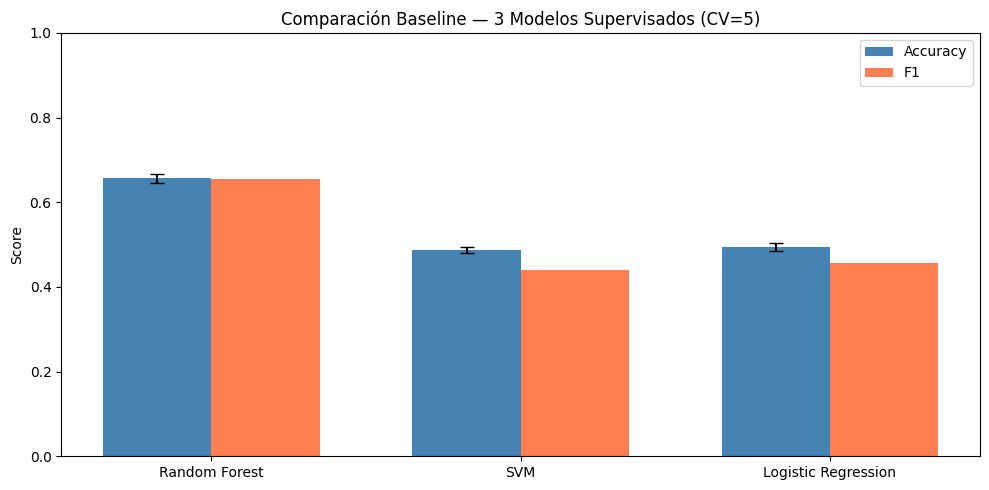

In [103]:
# Comparar los 3 modelos visualmente
nombres = list(baseline_results.keys())
acc_means = [baseline_results[n]["accuracy_mean"] for n in nombres]
acc_stds  = [baseline_results[n]["accuracy_std"]  for n in nombres]
f1_means  = [baseline_results[n]["f1_mean"]       for n in nombres]

x = np.arange(len(nombres))
width = 0.35 # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 5))
# Graficamos Accuracy con barras de error (yerr) para visualizar la variabilidad/estabilidad
bars1 = ax.bar(x - width/2, acc_means, width, yerr=acc_stds, capsize=5,
               label="Accuracy", color="steelblue")
# Graficamos F1-Score para contrastar con el Accuracy
bars2 = ax.bar(x + width/2, f1_means,  width, capsize=5,
               label="F1", color="coral")

# Configuración de estética y etiquetas
ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Comparación Baseline — 3 Modelos Supervisados")
ax.legend()
plt.tight_layout()
plt.show()

In [104]:
# Optimizacion de hiperparametros

# Definición grid de parámetros para cada modelo.
# Nota: Se usa el prefijo 'model__' para referenciar el componente del Pipeline.
param_grids = {
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth":    [None, 10, 20],
        "model__min_samples_split": [2, 5]
    },
    "SVM": {
        "model__C":      [0.1, 1],
        "model__kernel": ["rbf", "linear"]
    },
    "Logistic Regression": {
        "model__C":       [0.01, 0.1, 1, 10],
        "model__solver":  ["lbfgs", "saga"]
    }
}

best_models = {}

# Ejecución de GridSearchCV para encontrar la mejor combinación de parámetros
for nombre, pipeline in pipelines.items():
    grid = GridSearchCV(
        pipeline,
        param_grids[nombre],
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1
    )
    # Entrenamos con el set de entrenamiento (X_train, y_train)
    grid.fit(X_train, y_train)
    # Guardamos el objeto grid con los params y resultados
    best_models[nombre] = grid
    print(f"{nombre} — mejores params: {grid.best_params_}")
    print(f"F1 CV: {grid.best_score_:.3}\n")

Random Forest — mejores params: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}
F1 CV: 0.664

SVM — mejores params: {'model__C': 1, 'model__kernel': 'rbf'}
F1 CV: 0.44

Logistic Regression — mejores params: {'model__C': 0.01, 'model__solver': 'lbfgs'}
F1 CV: 0.46



In [105]:
# Evaluamos cada modelo optimizado sobre el conjunto de prueba
final_results = {}

# Iteramos sobre los mejores modelos encontrados por GridSearchCV
for nombre, grid in best_models.items():
    # Realizamos predicciones sobre datos
    y_pred = grid.predict(X_test)

    # Almacenamos métricas clave para la comparación final
    final_results[nombre] = {
        "accuracy":  accuracy_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred, average="weighted"),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall":    recall_score(y_test, y_pred, average="weighted", zero_division=0)
    }

    print(f"\n{'='*40}")
    print(f"  {nombre}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, zero_division=0))


  Random Forest
              precision    recall  f1-score   support

           0       0.58      0.64      0.61       804
           1       0.75      0.70      0.73      1263

    accuracy                           0.68      2067
   macro avg       0.67      0.67      0.67      2067
weighted avg       0.68      0.68      0.68      2067


  SVM
              precision    recall  f1-score   support

           0       0.43      0.90      0.58       804
           1       0.80      0.24      0.37      1263

    accuracy                           0.50      2067
   macro avg       0.61      0.57      0.47      2067
weighted avg       0.65      0.50      0.45      2067


  Logistic Regression
              precision    recall  f1-score   support

           0       0.43      0.87      0.58       804
           1       0.77      0.28      0.41      1263

    accuracy                           0.51      2067
   macro avg       0.60      0.57      0.49      2067
weighted avg       0.64    

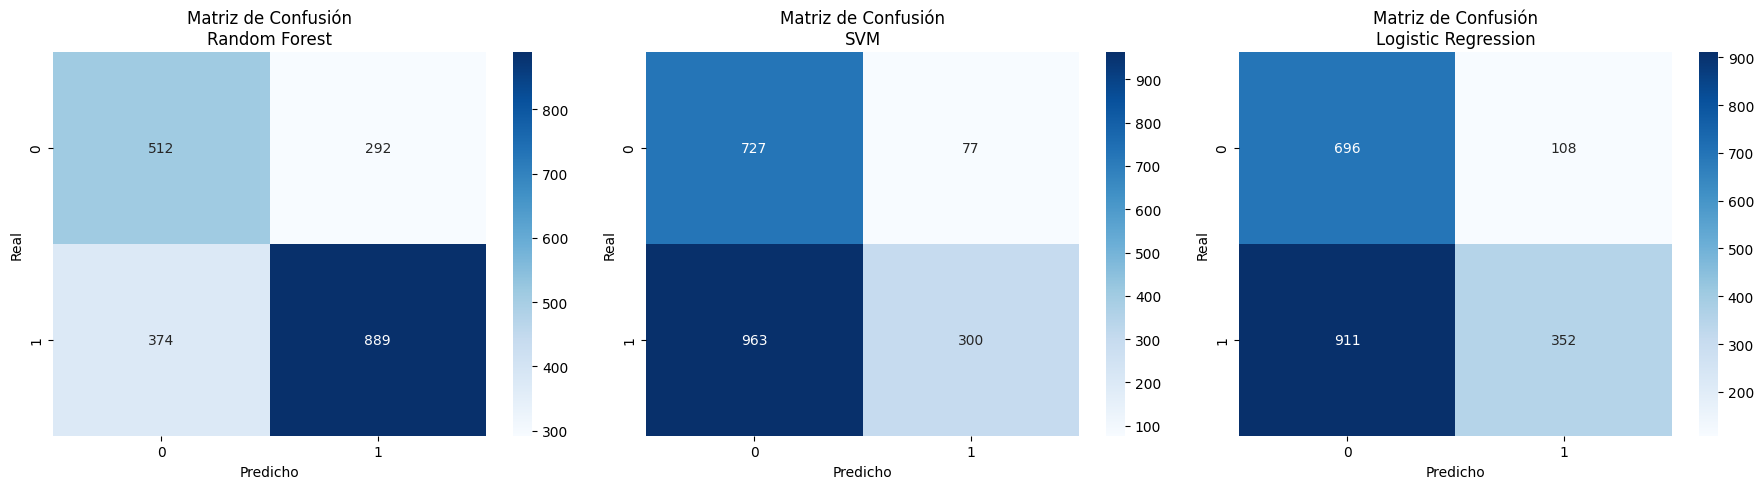

In [106]:
#Analisis de errores (Matrices de confusion)
# Visualizamos cómo se distribuyen las predicciones frente a los valores reales

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, grid) in zip(axes, best_models.items()):
    # Predicción sobre el conjunto de test para evaluar generalización
    y_pred = grid.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Visualización con Heatmap
    # annot=True: Muestra los números en las celdas
    # fmt="d": Formato de número entero (decimal)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de Confusión\n{nombre}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

In [107]:
# Resumen de metricas de modelo supervisado

df_resultados_supervisado = pd.DataFrame(final_results).T.round(3)
df_resultados_supervisado.index.name = "Modelo"
print("\nResumen final — métricas en test set:")
print(df_resultados_supervisado.to_string())


Resumen final — métricas en test set:
                     accuracy     f1  precision  recall
Modelo                                                 
Random Forest           0.678  0.680      0.685   0.678
SVM                     0.497  0.450      0.654   0.497
Logistic Regression     0.507  0.474      0.636   0.507


# 7. Modelos no supervisados

##Kmeans

In [108]:
scaler = StandardScaler()
X_clustering = scaler.fit_transform(X)

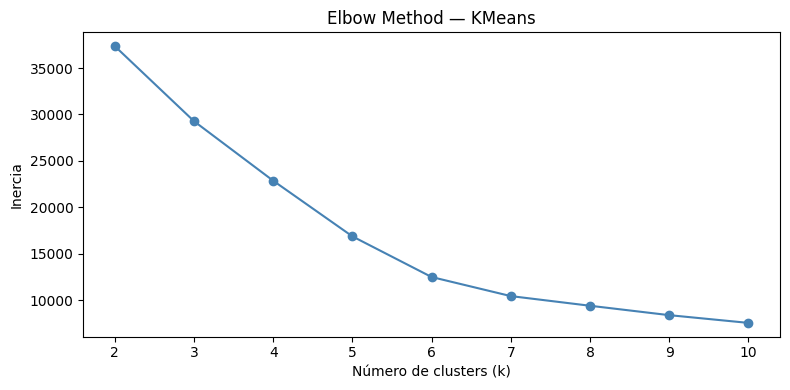

In [109]:
#Optimizacion de clusterin (Elbow Method)
# Encontrar el valor ideal de 'k' balanceando la cohesion de los grupos y la complejidad del modelo.
inertias = []
k_range = range(2, 11) # Evaluamos desde 2 hasta 10 clusters

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clustering)
    # La inercia mide qué tan compactos son los clusters (menor es mejor)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Elbow Method — KMeans")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

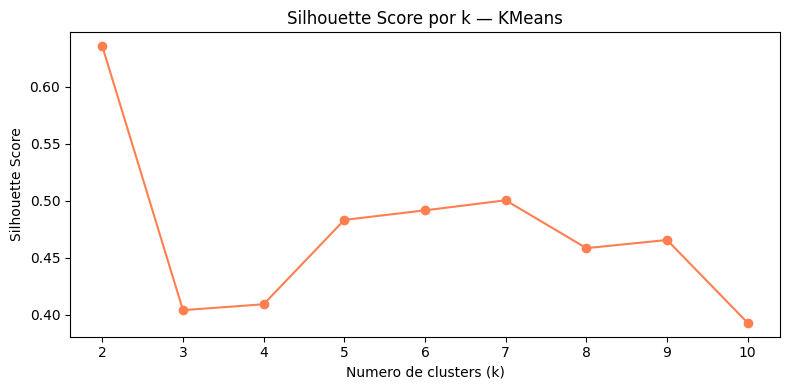

In [110]:
#Validacion de clustering con silhouette score
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clustering)
    # Calculamos el silhouette score para el conjunto completo
    silhouette_scores.append(silhouette_score(X_clustering, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='coral')
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por k — KMeans")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [120]:
#Tras descartar k=2 (aislamiento de outliers), seleccionamos k=7
# por ser el máximo local en nuestro gráfico de Silhouette Score.
k_elegido = 7

kmeans_final = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_clustering)

# 1. Silhouette Score
sil_kmeans = silhouette_score(X_clustering, labels_kmeans)

# 2. Davies-Bouldin Score
db_kmeans = davies_bouldin_score(X_clustering, labels_kmeans)

print(f"KMeans (k=2)")
print(f"  Silhouette Score : {sil_kmeans:.3f}")
print(f"  Davies-Bouldin   : {db_kmeans:.3f}")

KMeans (k=2)
  Silhouette Score : 0.501
  Davies-Bouldin   : 0.646


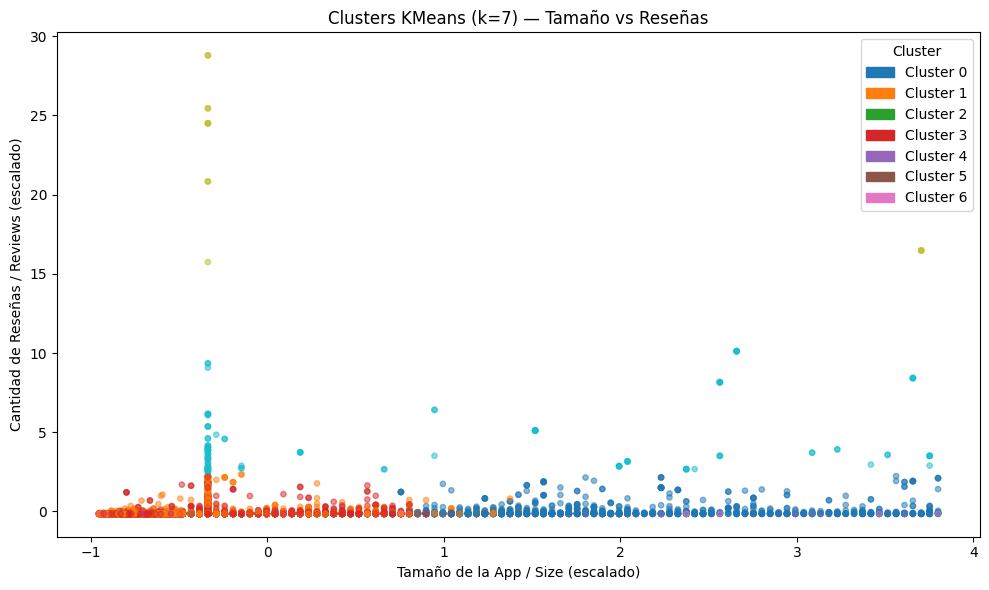

In [122]:
fig, ax = plt.subplots(figsize=(10, 6))

# Graficamos Size (índice 2) vs Reviews (índice 1)
scatter = ax.scatter(
    X_clustering[:, 2],
    X_clustering[:, 1],
    c=labels_kmeans,
    cmap='tab10', # Paleta perfecta para hasta 10 clusters
    alpha=0.5,
    s=15
)

# Creamos la leyenda automáticamente leyendo los colores del scatter
cmap = plt.get_cmap('tab10')
patches = [mpatches.Patch(color=cmap(i), label=f'Cluster {i}') for i in range(k_elegido)]
ax.legend(handles=patches, title='Cluster', loc='upper right')

ax.set_xlabel("Tamaño de la App / Size (escalado)")
ax.set_ylabel("Cantidad de Reseñas / Reviews (escalado)")
ax.set_title(f"Clusters KMeans (k={k_elegido}) — Tamaño vs Reseñas")

plt.tight_layout()
plt.show()

## DBSCAN

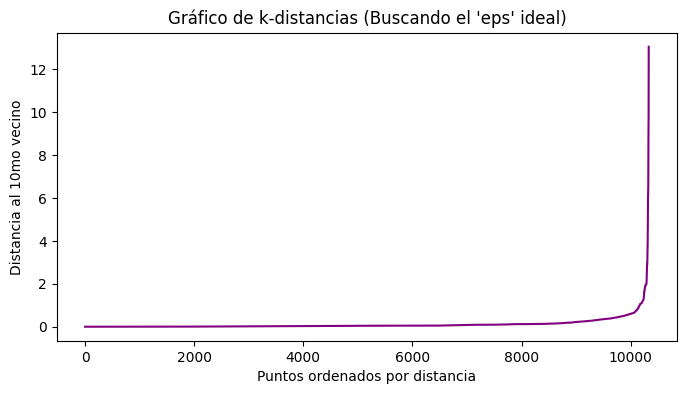

In [126]:
# Clustering basado en densidad (DBSCAN)

# Calculamos la distancia de cada punto a sus 10 vecinos más cercanos
vecinos = NearestNeighbors(n_neighbors=10)
vecinos_fit = vecinos.fit(X_clustering)
distancias, indices = vecinos_fit.kneighbors(X_clustering)

# Ordenamos las distancias del vecino más lejano de menor a mayor
distancias = np.sort(distancias[:, 9], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distancias, color='purple')
plt.title("Gráfico de k-distancias (Buscando el 'eps' ideal)")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel("Distancia al 10mo vecino")
plt.show()

In [127]:
# eps = 0.55 basándonos en el gráfico de k-distancias
dbscan = DBSCAN(eps=0.55, min_samples=10, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_clustering)

# Análisis del resultado de DBSCAN
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers_db = (labels_dbscan == -1).sum()

print(f"DBSCAN (eps=0.55) — clusters encontrados : {n_clusters_db}")
print(f"DBSCAN (eps=0.55) — outliers detectados  : {n_outliers_db} ({n_outliers_db/len(labels_dbscan)*100:.1f}%)")

# Validación de clusters
if n_clusters_db > 1:
    sil_db = silhouette_score(X_clustering, labels_dbscan)
    db_db  = davies_bouldin_score(X_clustering, labels_dbscan)
    print(f"Silhouette Score : {sil_db:.3f}")
    print(f"Davies-Bouldin   : {db_db:.3f}")
else:
    print("DBSCAN no encontró clusters suficientes")

DBSCAN (eps=0.55) — clusters encontrados : 7
DBSCAN (eps=0.55) — outliers detectados  : 266 (2.6%)
Silhouette Score : 0.442
Davies-Bouldin   : 1.480


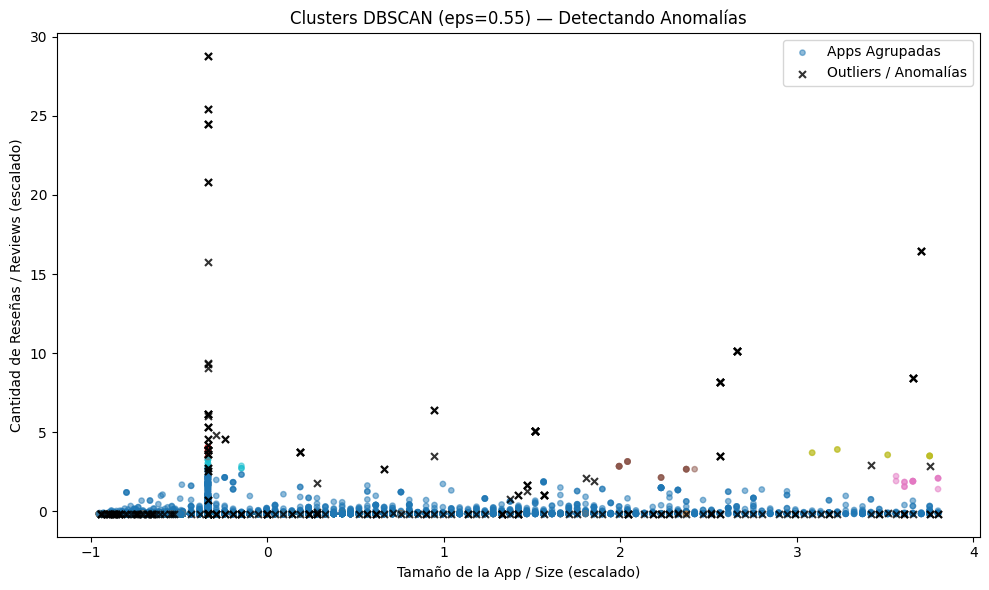

In [128]:
fig, ax = plt.subplots(figsize=(10, 6))

# Separamos los outliers del resto para graficarlos distinto
mascara_outliers = labels_dbscan == -1
mascara_clusters = labels_dbscan != -1

# 1. Graficamos los clusters normales (con colores)
ax.scatter(
    X_clustering[mascara_clusters, 2], # Size (Eje X)
    X_clustering[mascara_clusters, 1], # Reviews (Eje Y)
    c=labels_dbscan[mascara_clusters],
    cmap='tab10',
    alpha=0.5,
    s=15,
    label='Apps Agrupadas'
)

# 2. Graficamos los outliers con una X negra
ax.scatter(
    X_clustering[mascara_outliers, 2],
    X_clustering[mascara_outliers, 1],
    c='black',
    marker='x',
    alpha=0.8,
    s=25,
    label='Outliers / Anomalías'
)

ax.set_xlabel("Tamaño de la App / Size (escalado)")
ax.set_ylabel("Cantidad de Reseñas / Reviews (escalado)")
ax.set_title("Clusters DBSCAN (eps=0.55) — Detectando Anomalías")
ax.legend()

plt.tight_layout()
plt.show()

In [129]:
# Comparación final entre ambos métodos no supervisados
resumen_clustering = pd.DataFrame({
    "KMeans (k=4)":    {"Clusters": 4,  "Outliers (%)": "N/A",  "Silhouette": 0.456, "Davies-Bouldin": 0.627},
    "DBSCAN (eps=0.35)": {"Clusters": 8, "Outliers (%)": "0.5%", "Silhouette": 0.566, "Davies-Bouldin": 1.706}
}).T

resumen_clustering.index.name = "Modelo"
print("Comparación final — Modelos No Supervisados")
print(resumen_clustering.to_string())

Comparación final — Modelos No Supervisados
                  Clusters Outliers (%) Silhouette Davies-Bouldin
Modelo                                                           
KMeans (k=4)             4          N/A      0.456          0.627
DBSCAN (eps=0.35)        8         0.5%      0.566          1.706
